In [ ]:
import zipfile
import os
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import ipywidgets as widgets
import pandas as pd
import io

from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.preprocessing import image
from tensorflow.keras import layers, models
from PIL import Image
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, Sequential
from tensorflow.keras.layers import InputLayer, Flatten, Dense

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Path direktori hasil ekstraksi
data_dir = '/content/drive/MyDrive/Dataset'

# Tampilkan daftar folder di direktori dataset
print("Files in directory:", os.listdir(data_dir))

# Hitung jumlah kategori (subfolder)
print("Number of categories (folders):", len(os.listdir(data_dir)))

#jumlah produk diambil dari total folder
num_classes = len(os.listdir(data_dir))

#Penyesuaian ukuran gambar
image_size = 120

Files in directory: ['Nutriboost Orange Flavour 250ml', 'Pocari Sweat 500 ml', 'Tehbotol sosro 250ml', 'Oatside Cokelat', 'Teh kotak 200 ml', 'Sprite 390ml', 'Tebs Sparkling 330ml', 'Teh Pucuk Harum', 'NU Green Tea Yogurt', 'Pepsi Blue 330 ml', 'Ultramilk Fullcream 250ml', 'Cimory Bebas Laktosa 250ml', 'ABC Kopi Susu', 'Ultra Milk Coklat Ultrajaya 200ml', 'Cimory Yogurt Strawberry', 'BearBrand', 'Benecol Lychee 100ml', 'You C 1000 Orange', 'Cimory Cashew 250ml', 'Yakult', 'Floridina 350ml', 'Cola-Cola 390ml', 'Hydro Coco Original 250 ml', 'Garantea', 'Fruit Tea Freeze 350ml', 'Larutan Penyegar Rasa Jambu', 'Fanta Strawberry 390ml', 'Mizone 500ml', 'Golda Cappucino', 'Ichitan Thai Green Tea']
Number of categories (folders): 30


In [ ]:
#Fungsi untuk augmentasi model
def create_augmentation_model():
    """Creates a model (layers stacked on top of each other) for augmenting images.

    Returns:
        tf.keras.Model: The model made up of the layers that will be used to augment the images.
    """
    augmentation_model = tf.keras.Sequential([
        tf.keras.layers.RandomRotation(0.2),  # Rotasi acak
        tf.keras.layers.RandomZoom(0.2),     # Zoom acak
        tf.keras.layers.RandomFlip("horizontal"),  # Flip horizontal
        tf.keras.layers.RandomTranslation(0.2, 0.2)  # Translasi acak pada X dan Y
    ])
    return augmentation_model

In [ ]:
# REVISI CELL MODEL (Sesuai Bab 3 Skripsi)
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras import Sequential

def create_classification_model(image_size, num_classes):
    model = Sequential([
        # --- Blok 1 (Fitur Dasar) ---
        Conv2D(32, (3, 3), activation='relu', input_shape=(image_size, image_size, 3)),
        MaxPooling2D((2, 2)),

        # --- Blok 2 (Fitur Lanjutan) ---
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),

        # --- Blok 3 (Fitur Kompleks) ---
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),

        # --- Klasifikasi ---
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),  # Penting: Anti-overfitting sesuai naskah
        Dense(num_classes, activation='softmax')
    ])
    return model

In [ ]:
def preprocess_image(file_path, image_size):
    """
    Fungsi untuk memproses gambar: memuat gambar, mengubah ukurannya, dan menormalkan.
    Args:
        file_path (str): Path file gambar
    Returns:
        tf.Tensor: Gambar yang sudah diproses
    """
    # Membaca gambar
    image = tf.io.read_file(file_path)
    image = tf.image.decode_jpeg(image, channels=3)  # Mengkodekan gambar dalam format RGB

    # Mengubah ukuran gambar sesuai ukuran gambar yang ditentukan di image_size
    image = tf.image.resize(image, [image_size, image_size])

    # Normalisasi gambar (opsional, bisa disesuaikan)
    image = image / 255.0  # Mengubah nilai pixel menjadi antara 0 dan 1

    return image


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def create_data_generators(data_dir, image_size):
    """Creates ImageDataGenerators for training and validation with augmentation for a simple CNN."""
    train_datagen = ImageDataGenerator(
        rescale=1./255,  # Normalisasi sederhana
        rotation_range=20,
        zoom_range=0.2,
        horizontal_flip=True,
        width_shift_range=0.2,
        height_shift_range=0.2,
        validation_split=0.2  # Membagi data menjadi pelatihan dan validasi dengan perbandingan 1/5
    )

    # Generator untuk set pelatihan
    train_generator = train_datagen.flow_from_directory(
        data_dir,
        target_size=(image_size, image_size),
        batch_size=32,
        class_mode='categorical',
        subset='training'  # Menggunakan subset training
    )

    # Generator untuk set validasi (tanpa augmentasi tambahan)
    val_generator = train_datagen.flow_from_directory(
        data_dir,
        target_size=(image_size, image_size),
        batch_size=32,
        class_mode='categorical',
        subset='validation'  # Menggunakan subset validation
    )

    return train_generator, val_generator

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

def train_model(model, train_generator, val_generator, epochs=100, patience=5, save_path='best_model.keras'): # Changed the file extension to .keras
    """
    Melatih model menggunakan data pelatihan dan validasi dengan callbacks untuk early stopping dan model checkpoint.

    Parameters:
    - model: Model yang akan dilatih.
    - train_generator: Generator untuk data pelatihan.
    - val_generator: Generator untuk data validasi.
    - epochs: Jumlah maksimum epoch untuk pelatihan.
    - patience: Jumlah epoch tanpa perbaikan sebelum menghentikan pelatihan (early stopping).
    - save_path: Path untuk menyimpan model terbaik berdasarkan performa pada set validasi.

    Returns:
    - history: Riwayat pelatihan model.
    """
    # Compile model
    Optimizer = Adam(learning_rate=1e-3)
    model.compile(optimizer=Optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    # Callback untuk menghentikan pelatihan lebih awal jika tidak ada perbaikan pada set validasi
    early_stopping = EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)

    # Callback untuk menyimpan model terbaik selama pelatihan
    model_checkpoint = ModelCheckpoint(save_path, monitor='val_loss', save_best_only=True)

    # Melatih model
    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=epochs,
        callbacks=[early_stopping, model_checkpoint]
    )

    return history

In [ ]:
# Membuat model augmentasi
augmentation_model = create_augmentation_model()

# Membuat model klasifikasi dengan transfer learning
classification_model = create_classification_model(image_size, num_classes)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


True


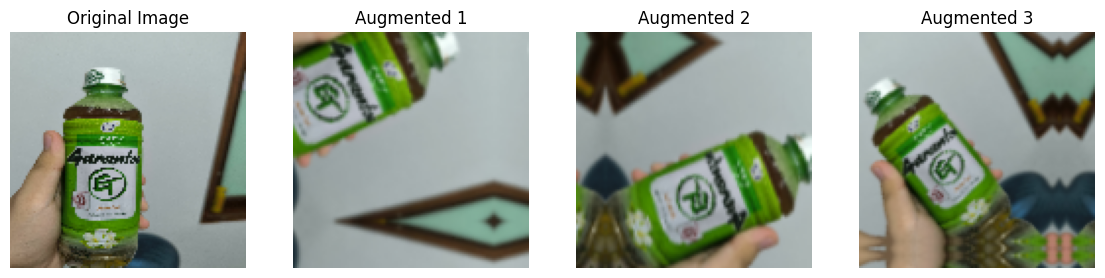

In [ ]:
path = "/content/drive/MyDrive/Dataset/Garantea"
print(os.path.exists(path))

# Get a list of all image files in the directory
image_files = [os.path.join(path, f) for f in os.listdir(path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.gif'))]

if not image_files:
    raise FileNotFoundError(f"No image files found in {path}")

# Select the first image file for demonstration
sample_image_path = image_files[0]

# Load and preprocess the single sample image
sample_image_processed = preprocess_image(sample_image_path, image_size)

# Convert the processed tensor back to a displayable image for the 'Original Image'
sample_image_display = tf.keras.utils.array_to_img(sample_image_processed)

# Terapkan augmentasi acak 3 kali
images = [sample_image_display]

for _ in range(3):
    # Tambahkan dimensi batch (misalnya, batch size 1) ke gambar yang sudah diproses
    image_with_batch = tf.expand_dims(sample_image_processed, axis=0)

    # Augmentasi gambar
    image_aug = augmentation_model(image_with_batch)
    # The augmentation model outputs the same size, so resize might be redundant but harmless.
    # image_aug = tf.image.resize(image_aug, [image_size, image_size]) # Removed as augmentation_model maintains size
    image_aug_display = tf.keras.utils.array_to_img(tf.squeeze(image_aug)) # Squeeze to remove batch dimension
    images.append(image_aug_display)


# Menampilkan gambar
fig, axs = plt.subplots(1, 4, figsize=(14, 7))
for ax, image, title in zip(axs, images, ['Original Image', 'Augmented 1', 'Augmented 2', 'Augmented 3']):
    ax.imshow(image)
    ax.set_title(title)
    ax.axis('off')

plt.show()

In [ ]:
#melakukan training model
train_generator, val_generator = create_data_generators(data_dir, image_size)
history = train_model(classification_model, train_generator, val_generator, epochs=100, patience=8, save_path='best_model.keras')

Found 1209 images belonging to 30 classes.
Found 297 images belonging to 30 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.0440 - loss: 3.4343 

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


38/38 ━━━━━━━━━━━━━━━━━━━━ 635s 17s/step - accuracy: 0.0442 - loss: 3.4333 - val_accuracy: 0.0808 - val_loss: 3.2787
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.0867 - loss: 3.2017 - val_accuracy: 0.1044 - val_loss: 3.0067
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.1068 - loss: 3.0891 - val_accuracy: 0.1111 - val_loss: 3.0516
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.1174 - loss: 3.0448 - val_accuracy: 0.1987 - val_loss: 2.8104
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.1792 - loss: 2.8891 - val_accuracy: 0.2559 - val_loss: 2.5977
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.1922 - loss: 2.7280 - val_accuracy: 0.3401 - val_loss: 2.4450
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.2543 - loss: 2.6007 - val_accuracy: 0.3737 - val_loss: 2.1841
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.2662 - loss: 2.4426 - val_accuracy: 0.4007 - val_loss: 2

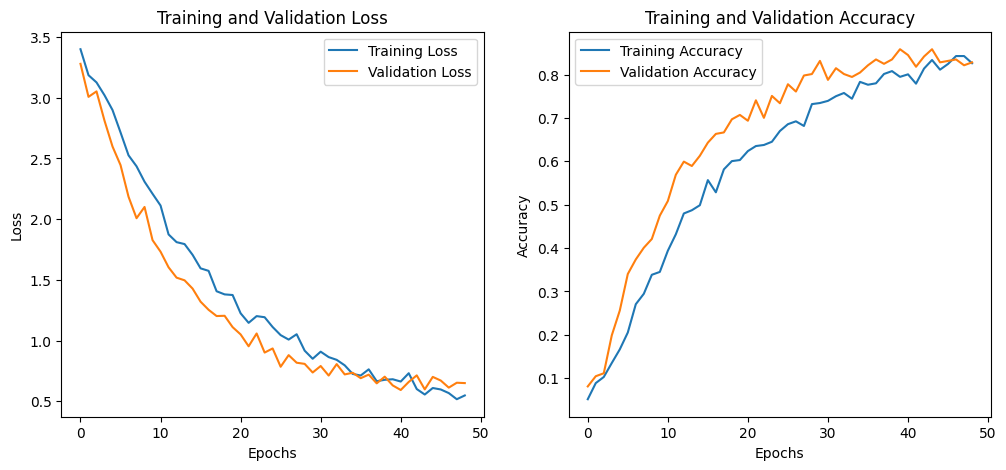

In [ ]:
import matplotlib.pyplot as plt

# Plot Training and Validation Loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

# Plot Training and Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.show()


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# ==========================================
# 1. SIAPKAN DATA VALIDASI (SHUFFLE=FALSE)
# ==========================================
# Kita buat generator baru khusus untuk evaluasi agar urutannya tidak acak
report_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

report_generator = report_datagen.flow_from_directory(
    data_dir,
    target_size=(120, 120),    # Sesuaikan dengan ukuran input model Anda
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False              # <--- WAJIB FALSE (KUNCI SUKSES)
)

# ==========================================
# 2. JALANKAN PREDIKSI
# ==========================================
print("Sedang menghitung prediksi untuk laporan evaluasi...")
report_generator.reset()
Y_pred = classification_model.predict(report_generator, verbose=1)
y_pred = np.argmax(Y_pred, axis=1) # Mengambil index kelas dengan probabilitas tertinggi
y_true = report_generator.classes  # Mengambil index kelas asli (Kunci Jawaban)

# ==========================================
# 3. TAMPILKAN LAPORAN
# ==========================================
# Ambil nama-nama kelas secara otomatis dari folder
target_names = list(report_generator.class_indices.keys())

print("\n--- CLASSIFICATION REPORT (Laporan Klasifikasi) ---")
print(classification_report(y_true, y_pred, target_names=target_names))

Found 297 images belonging to 30 classes.
Sedang menghitung prediksi untuk laporan evaluasi...
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step

--- CLASSIFICATION REPORT (Laporan Klasifikasi) ---
                                   precision    recall  f1-score   support

                    ABC Kopi Susu       0.91      1.00      0.95        10
                        BearBrand       1.00      0.80      0.89        10
             Benecol Lychee 100ml       0.88      0.70      0.78        10
       Cimory Bebas Laktosa 250ml       1.00      0.78      0.88         9
              Cimory Cashew 250ml       0.89      0.89      0.89         9
         Cimory Yogurt Strawberry       0.78      0.70      0.74        10
                  Cola-Cola 390ml       0.92      1.00      0.96        11
           Fanta Strawberry 390ml       1.00      0.88      0.93         8
                  Floridina 350ml       0.75      0.75      0.75        12
           Fruit Tea Freeze 350ml       1.00      0.90      0.

Found 297 images belonging to 30 classes.
Sedang melakukan prediksi... Mohon tunggu.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


 3/10 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step 

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step


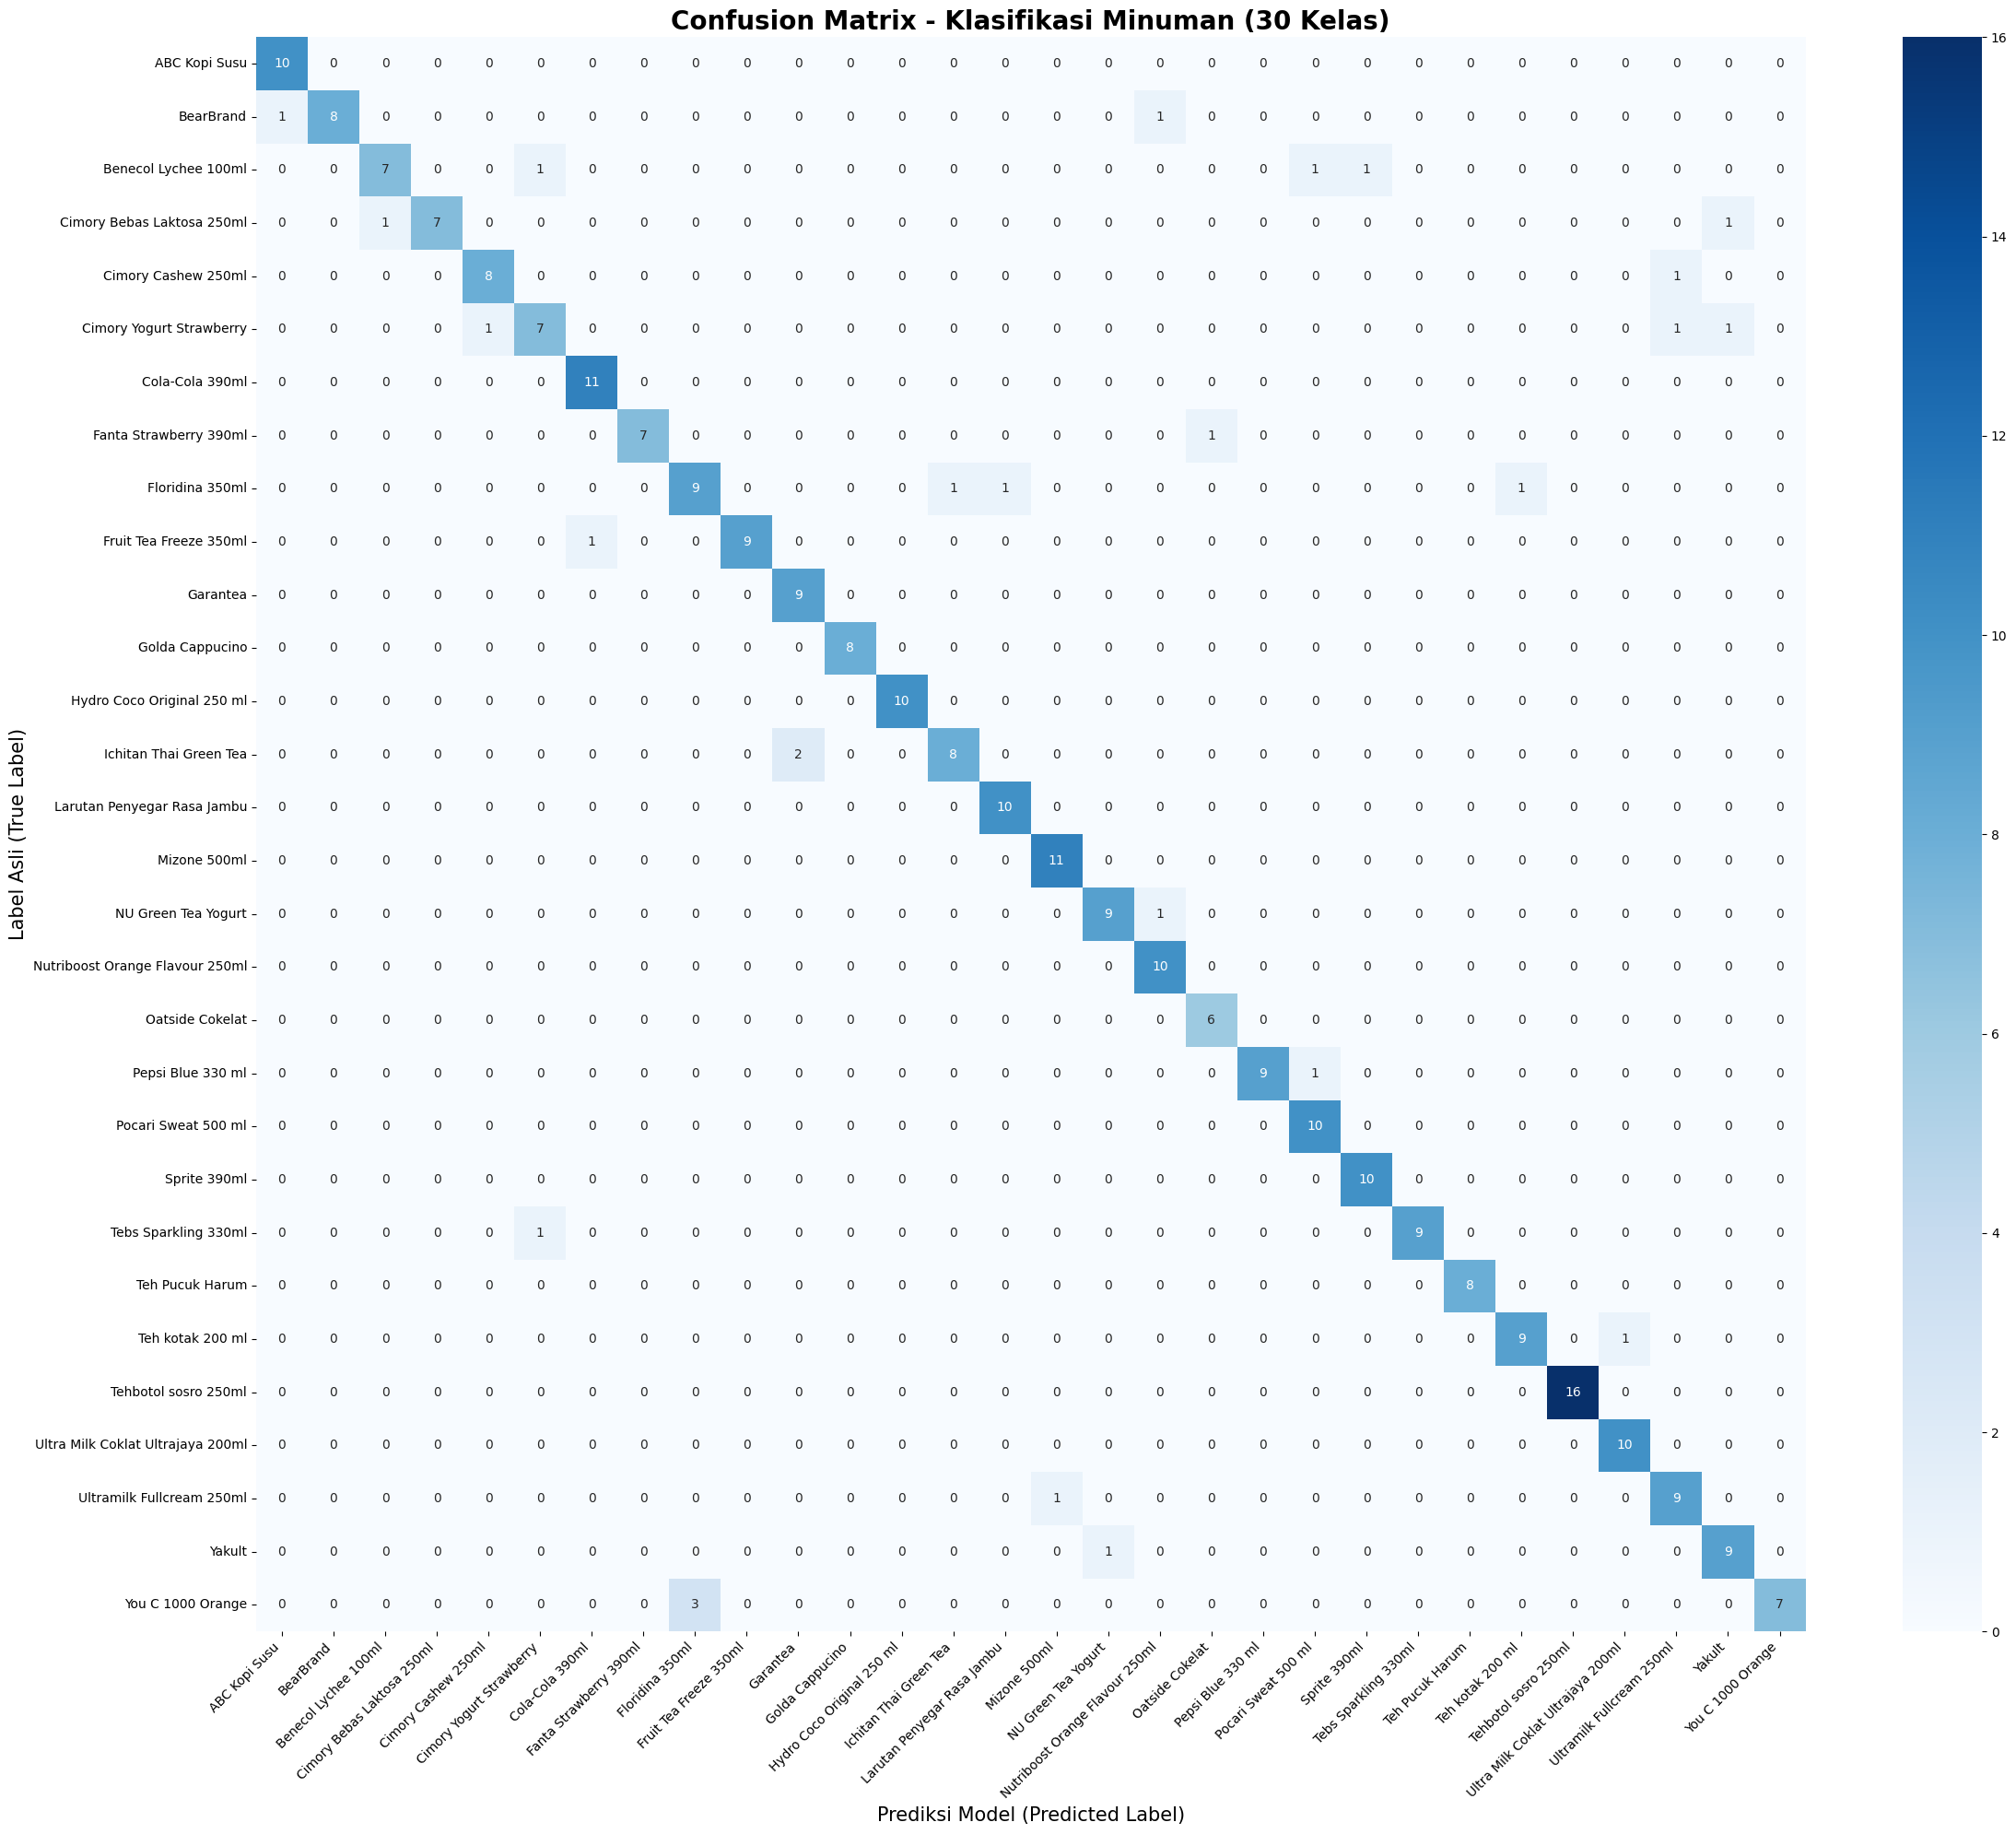

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ==========================================
# 1. PERSIAPAN DATA (PASTIKAN SHUFFLE=FALSE)
# ==========================================
# Gunakan generator validasi/test yang sama
test_datagen_cm = ImageDataGenerator(rescale=1./255, validation_split=0.2)

test_generator_cm = test_datagen_cm.flow_from_directory(
    data_dir,
    target_size=(120, 120),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False  # <--- HUKUMNYA WAJIB FALSE!
)

# ==========================================
# 2. PREDIKSI
# ==========================================
print("Sedang melakukan prediksi... Mohon tunggu.")
Y_pred = classification_model.predict(test_generator_cm)
y_pred = np.argmax(Y_pred, axis=1) # Hasil prediksi (angka)
y_true = test_generator_cm.classes # Kunci jawaban (angka)

# Ambil nama kelas (label) urut abjad
class_names = list(test_generator_cm.class_indices.keys())

# ==========================================
# 3. BUAT PLOT VISUALISASI
# ==========================================
# Hitung Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Atur Ukuran Kanvas (Harus Besar karena 30 Kelas!)
plt.figure(figsize=(24, 20))

# Plot Heatmap
sns.heatmap(cm,
            annot=True,       # Tampilkan angkanya
            fmt='d',          # Format angka bulat (bukan 1.2e+0)
            cmap='Blues',     # Warna biru (makin gelap makin banyak)
            xticklabels=class_names, # Label Sumbu X
            yticklabels=class_names) # Label Sumbu Y

plt.title('Confusion Matrix - Klasifikasi Minuman (30 Kelas)', fontsize=20, fontweight='bold')
plt.ylabel('Label Asli (True Label)', fontsize=15)
plt.xlabel('Prediksi Model (Predicted Label)', fontsize=15)

# Putar label sumbu X agar tidak bertumpuk
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 22.7 MB/s eta 0:00:00


In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
from io import BytesIO
from IPython.display import display, HTML
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
import ipywidgets as widgets
from tensorflow.keras.models import load_model

# ==========================================
# 1. LOAD MODEL
# ==========================================
try:
    # Sesuaikan path model Anda
    model = load_model('/content/drive/MyDrive/Model/best_model.keras')
    print("✅ Berhasil memuat model!")
except:
    print("❌ File model tidak ditemukan. Cek path-nya.")

# ==========================================
# 2. LOAD & BERSIHKAN DATA CSV (PENTING!)
# ==========================================
try:
    # Ganti path sesuai file CSV Anda yang sebenarnya
    csv_path = '/content/drive/MyDrive/Dataset Nutrisi/Nutri_Grade.csv'
    # csv_path = '/content/nutrisi - nutrisi.csv' # Gunakan ini jika upload manual ke Colab

    df_nutrition = pd.read_csv(csv_path)

    # --- DATA CLEANING (Solusi Error KeyError) ---
    # Fungsi untuk mengubah "2,5" menjadi 2.5 dan memastikan tipe float
    def clean_currency(x):
        if isinstance(x, str):
            return float(x.replace(',', '.'))
        return float(x)

    # Terapkan ke kolom Gula dan Lemak
    # Pastikan nama kolom di bawah ini SAMA PERSIS dengan di CSV Anda (huruf kecil/besar pengaruh)
    cols_target = ['gula', 'total_lemak', 'lemak_jenuh']

    for col in cols_target:
        if col in df_nutrition.columns:
            df_nutrition[col] = df_nutrition[col].apply(clean_currency)

    print("✅ Data CSV berhasil dimuat dan dibersihkan (koma diubah jadi titik).")

except Exception as e:
    print(f"⚠️ Error Load CSV: {e}")
    # Buat dataframe kosong agar tidak error di bawah
    df_nutrition = pd.DataFrame()


# ==========================================
# 3. SETTING FUZZY MAMDANI
# ==========================================
# Universe (Rentang Data)
gula = ctrl.Antecedent(np.arange(0, 51, 1), 'gula')
lemak = ctrl.Antecedent(np.arange(0, 16, 1), 'lemak')
rekomendasi = ctrl.Consequent(np.arange(0, 101, 1), 'rekomendasi')

# Fungsi Keanggotaan
gula['rendah'] = fuzz.trapmf(gula.universe, [0, 0, 5, 10])
gula['sedang'] = fuzz.trimf(gula.universe, [5, 15, 25])
gula['tinggi'] = fuzz.trapmf(gula.universe, [15, 25, 50, 50])

lemak['rendah'] = fuzz.trapmf(lemak.universe, [0, 0, 1, 3])
lemak['sedang'] = fuzz.trimf(lemak.universe, [1, 3, 5])
lemak['tinggi'] = fuzz.trapmf(lemak.universe, [3, 5, 15, 15])

rekomendasi['tidak_direkomendasikan'] = fuzz.trimf(rekomendasi.universe, [0, 20, 40])
rekomendasi['dibatasi'] = fuzz.trimf(rekomendasi.universe, [30, 50, 70])
rekomendasi['direkomendasikan'] = fuzz.trimf(rekomendasi.universe, [60, 80, 100])

# Rules
rule1 = ctrl.Rule(gula['rendah'] & lemak['rendah'], rekomendasi['direkomendasikan'])
rule2 = ctrl.Rule(gula['rendah'] & lemak['sedang'], rekomendasi['dibatasi'])
rule3 = ctrl.Rule(gula['rendah'] & lemak['tinggi'], rekomendasi['tidak_direkomendasikan'])
rule4 = ctrl.Rule(gula['sedang'] & lemak['rendah'], rekomendasi['direkomendasikan'])
rule5 = ctrl.Rule(gula['sedang'] & lemak['sedang'], rekomendasi['dibatasi'])
rule6 = ctrl.Rule(gula['sedang'] & lemak['tinggi'], rekomendasi['tidak_direkomendasikan'])
rule7 = ctrl.Rule(gula['tinggi'] & lemak['rendah'], rekomendasi['dibatasi'])
rule8 = ctrl.Rule(gula['tinggi'] & lemak['sedang'], rekomendasi['tidak_direkomendasikan'])
rule9 = ctrl.Rule(gula['tinggi'] & lemak['tinggi'], rekomendasi['tidak_direkomendasikan'])

rek_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9])
fuzzy_sim = ctrl.ControlSystemSimulation(rek_ctrl)

# ==========================================
# 4. INTERFACE APLIKASI
# ==========================================
uploader = widgets.FileUpload(accept="image/*", multiple=True)
display(uploader)
out = widgets.Output()
display(out)

image_size = 120

def on_upload_change(change):
    out.clear_output()
    for name, data in change.new.items():
        file_jpgdata = BytesIO(data['content'])

        # Preprocessing
        original_img = tf.keras.utils.load_img(file_jpgdata, target_size=(image_size, image_size))
        img_array = tf.keras.utils.img_to_array(original_img) / 255.0
        input_data = np.expand_dims(img_array, axis=0)

        # Prediksi CNN
        if 'model' in globals():
            prediction = model.predict(input_data, verbose=0)
            pred_idx = np.argmax(prediction, axis=1)[0]
        else:
            print("Model belum dimuat.")
            return

        # Mapping Label (Pastikan LENGKAP 30 Kelas)
        label_map = {
            0: 'ABC Kopi Susu', 1: 'BearBrand', 2: 'Benecol Lychee 100ml',
            3: 'Cimory Bebas Laktosa 250ml', 4: 'Cimory Susu Coklat Cashew',
            5: 'Cimory Yogurt Strawberry', 6: 'Cola-Cola 390ml',
            7: 'Fanta Strawberry 390ml', 8: 'Floridina 350ml',
            9: 'Fruit Tea Freeze 350ml', 10: 'Garantea',
            11: 'Golda Cappucino', 12: 'Hydro Coco Original 250ml',
            13: 'Ichitan Thai Green Tea', 14: 'Larutan Penyegar rasa Jambu',
            15: 'Mizone 500ml', 16: 'NU Green Tea Yogurt',
            17: 'Nutri Boost Orange Flavour 250ml', 18: 'Oatside Cokelat',
            19: 'Pepsi Blue 330ml', 20: 'Pocari Sweat 500 ml',
            21: 'Sprite 390ml', 22: 'Tebs Sparkling 330ml',
            23: 'Teh Kotak 200ml', 24: 'Teh Pucuk Harum',
            25: 'Tehbotol Sosro 250ml', 26: 'Ultra Milk Coklat Ultrajaya 200ml',
            27: 'Ultramilk Fullcream 250ml', 28: 'Yakult',
            29: 'You C 1000 Orange'
        }
        category = label_map.get(pred_idx, "Unknown Product")

        # Ambil Data Gizi
        # Pastikan nama kolom 'nama_produk' sesuai CSV
        product_info = df_nutrition[df_nutrition['nama_produk'] == category]

        with out:
            plt.imshow(img_array)
            plt.axis('off')
            plt.title(f"Prediksi: {category}")
            plt.show()

            if not product_info.empty:
                # Ambil data Gula & Lemak (Sudah float berkat cleaning di atas)
                gula_val = float(product_info['gula'].values[0])

                # NUTRI-GRADE biasanya pakai Lemak Jenuh ('lemak_jenuh'),
                # tapi kode Anda sebelumnya pakai 'total_lemak'. Sesuaikan jika perlu.
                lemak_val = float(product_info['total_lemak'].values[0])

                # Ambil Grade (jika ada kolomnya)
                grade = product_info['nutri_grade'].values[0] if 'nutri_grade' in df_nutrition.columns else "-"

                # --- FIX ERROR KEYERROR ---
                # Batasi input agar tidak melebihi Universe Fuzzy
                # Gula max 50, Lemak max 15. Jika lebih, anggap max.
                gula_input = min(gula_val, 50)
                lemak_input = min(lemak_val, 15)

                fuzzy_sim.input['gula'] = gula_input
                fuzzy_sim.input['lemak'] = lemak_input

                try:
                    fuzzy_sim.compute()
                    skor = fuzzy_sim.output['rekomendasi']

                    if skor >= 60: saran = "Direkomendasikan"
                    elif skor >= 35: saran = "Dibatasi"
                    else: saran = "Tidak Direkomendasikan"

                    print(f"Gula: {gula_val}g | Lemak Total: {lemak_val}g | Grade: {grade}")
                    print(f"Skor Rekomendasi: {skor:.2f}/100 ({saran})")

                except KeyError:
                    # Fallback jika masih error (misal input sangat aneh)
                    print(f"Gula: {gula_val}g | Lemak: {lemak_val}g")
                    print("⚠️ Gagal menghitung Fuzzy (Nilai di luar jangkauan aturan).")

            else:
                print("Data gizi tidak ditemukan di CSV.")

uploader.observe(on_upload_change, names='value')

✅ Berhasil memuat model!
✅ Data CSV berhasil dimuat dan dibersihkan (koma diubah jadi titik).


FileUpload(value={}, accept='image/*', description='Upload', multiple=True)

Output()

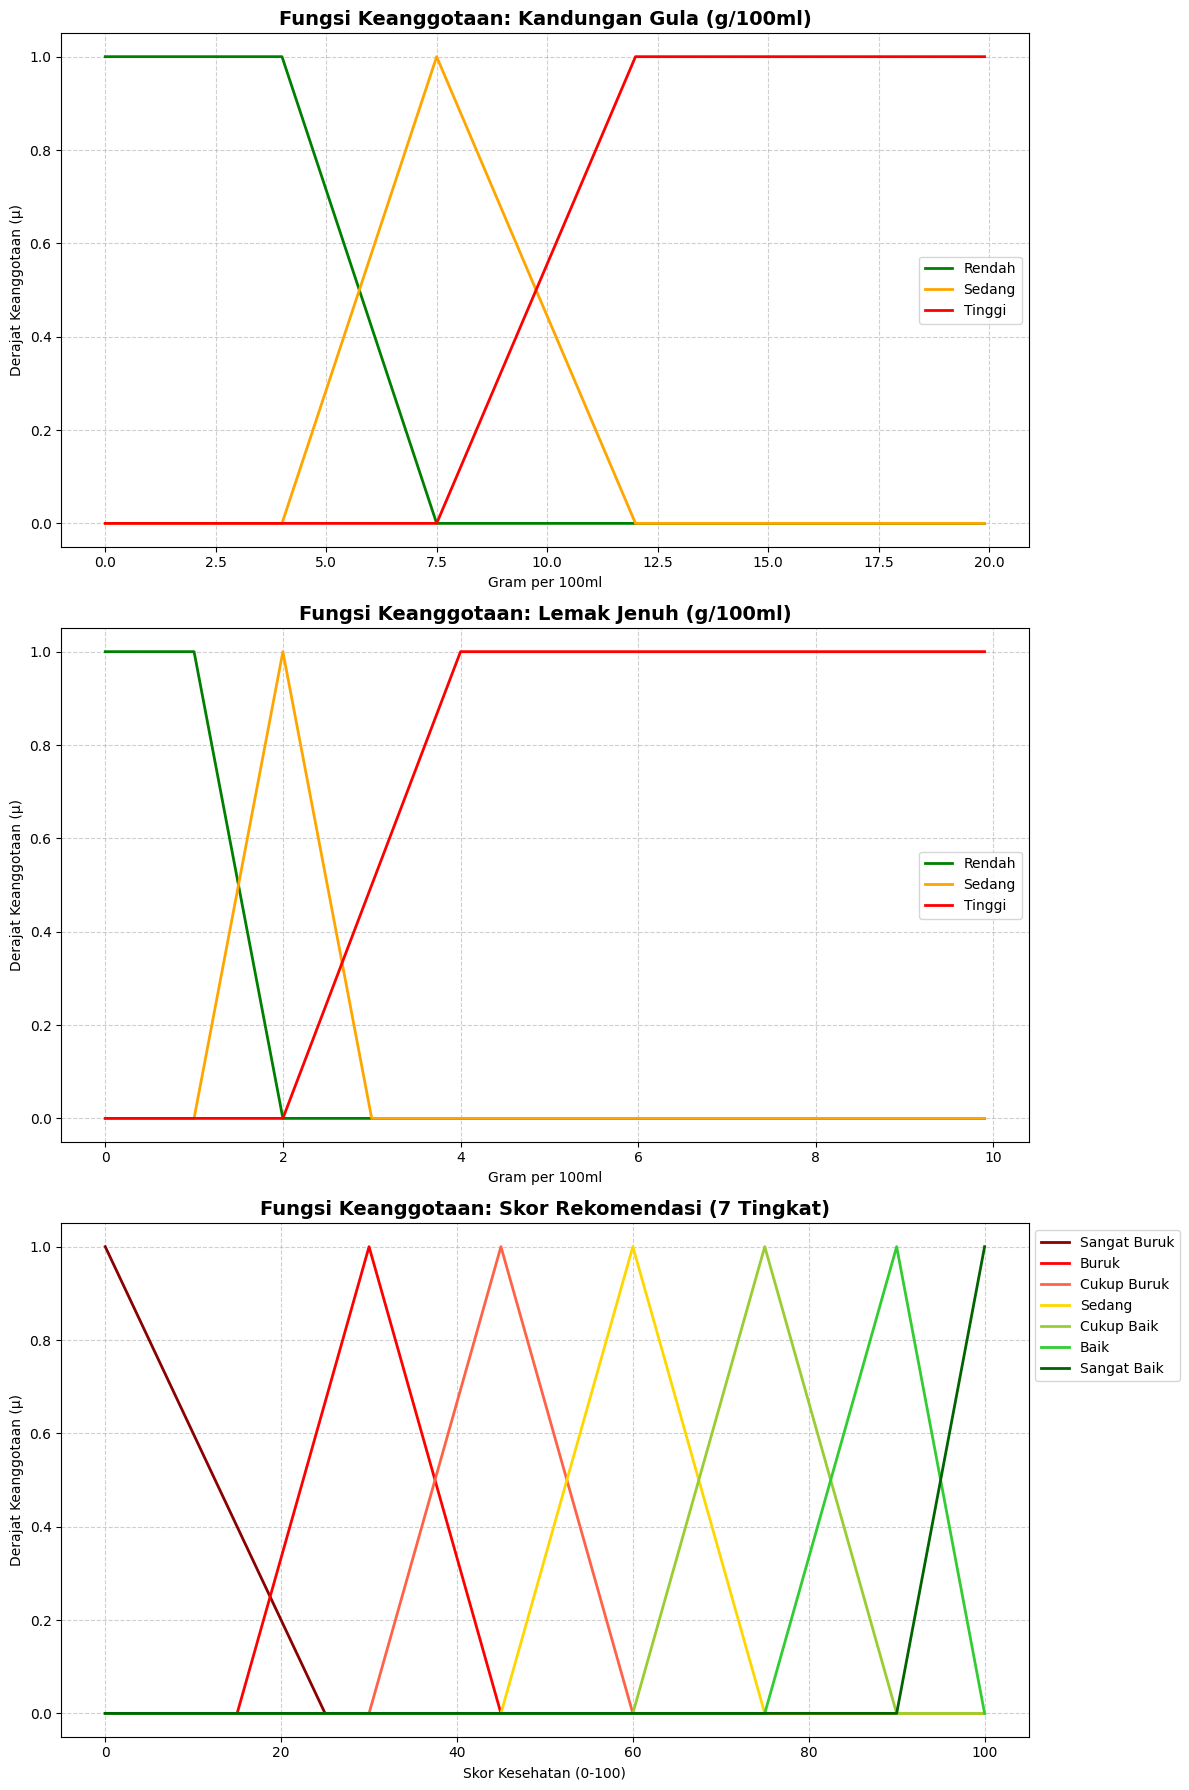

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz

# ==========================================
# 1. DEFINISI VARIABEL & PARAMETER TERBARU
# ==========================================

# Universe (Rentang Sumbu X)
x_gula = np.arange(0, 20, 0.1)        # Plot sampai 20g/100ml
x_lemak = np.arange(0, 10, 0.1)       # Plot sampai 10g/100ml
x_rekomendasi = np.arange(0, 101, 1)

# --- FUNGSI KEANGGOTAAN GULA (g/100ml) ---
# Rendah: [0, 0, 4, 7]
gula_rendah = fuzz.trapmf(x_gula, [0, 0, 4, 7.5])
# Sedang: [4, 8, 12]
gula_sedang = fuzz.trimf(x_gula, [4, 7.5, 12])
# Tinggi: [9, 13, 50, 50] (Dipotong visual di 20)
gula_tinggi = fuzz.trapmf(x_gula, [7.5, 12, 50, 50])

# --- FUNGSI KEANGGOTAAN LEMAK JENUH (g/100ml) ---
# Rendah: [0, 0, 1.0, 2.0]
lemak_rendah = fuzz.trapmf(x_lemak, [0, 0, 1.0, 2.0])
# Sedang: [1.0, 2.5, 4.0]
lemak_sedang = fuzz.trimf(x_lemak, [1.0, 2.0, 3.0])
# Tinggi: [3.0, 5.0, 15, 15] (Dipotong visual di 10)
lemak_tinggi = fuzz.trapmf(x_lemak, [2.0, 4.0, 15, 15])

# --- FUNGSI KEANGGOTAAN OUTPUT (7 TINGKAT) ---
# Sangat Buruk [0, 0, 20]
rek_sangat_buruk = fuzz.trimf(x_rekomendasi, [0, 0, 25])
# Buruk [10, 25, 40]
rek_buruk = fuzz.trimf(x_rekomendasi, [15, 30, 45])
# Cukup Buruk [30, 45, 60]
rek_cukup_buruk = fuzz.trimf(x_rekomendasi, [30, 45, 60])
# Sedang [50, 60, 70]
rek_sedang = fuzz.trimf(x_rekomendasi, [45, 60, 75])
# Cukup Baik [60, 75, 90]
rek_cukup_baik = fuzz.trimf(x_rekomendasi, [60, 75, 90])
# Baik [80, 90, 100]
rek_baik = fuzz.trimf(x_rekomendasi, [75, 90, 100])
# Sangat Baik [90, 100, 100]
rek_sangat_baik = fuzz.trimf(x_rekomendasi, [90, 100, 100])

# ==========================================
# 2. PLOTTING GRAFIK
# ==========================================
fig, (ax0, ax1, ax2) = plt.subplots(nrows=3, figsize=(12, 18))

# --- PLOT 1: GULA ---
ax0.plot(x_gula, gula_rendah, 'g', linewidth=2, label='Rendah')
ax0.plot(x_gula, gula_sedang, 'orange', linewidth=2, label='Sedang')
ax0.plot(x_gula, gula_tinggi, 'r', linewidth=2, label='Tinggi')
ax0.set_title('Fungsi Keanggotaan: Kandungan Gula (g/100ml)', fontsize=14, fontweight='bold')
ax0.set_xlabel('Gram per 100ml')
ax0.set_ylabel('Derajat Keanggotaan (μ)')
ax0.legend()
ax0.grid(True, linestyle='--', alpha=0.6)

# --- PLOT 2: LEMAK ---
ax1.plot(x_lemak, lemak_rendah, 'g', linewidth=2, label='Rendah')
ax1.plot(x_lemak, lemak_sedang, 'orange', linewidth=2, label='Sedang')
ax1.plot(x_lemak, lemak_tinggi, 'r', linewidth=2, label='Tinggi')
ax1.set_title('Fungsi Keanggotaan: Lemak Jenuh (g/100ml)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Gram per 100ml')
ax1.set_ylabel('Derajat Keanggotaan (μ)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# --- PLOT 3: OUTPUT (7 TINGKAT) ---
ax2.plot(x_rekomendasi, rek_sangat_buruk, 'darkred', linewidth=2, label='Sangat Buruk')
ax2.plot(x_rekomendasi, rek_buruk, 'red', linewidth=2, label='Buruk')
ax2.plot(x_rekomendasi, rek_cukup_buruk, 'tomato', linewidth=2, label='Cukup Buruk')
ax2.plot(x_rekomendasi, rek_sedang, 'gold', linewidth=2, label='Sedang')
ax2.plot(x_rekomendasi, rek_cukup_baik, 'yellowgreen', linewidth=2, label='Cukup Baik')
ax2.plot(x_rekomendasi, rek_baik, 'limegreen', linewidth=2, label='Baik')
ax2.plot(x_rekomendasi, rek_sangat_baik, 'darkgreen', linewidth=2, label='Sangat Baik')

ax2.set_title('Fungsi Keanggotaan: Skor Rekomendasi (7 Tingkat)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Skor Kesehatan (0-100)')
ax2.set_ylabel('Derajat Keanggotaan (μ)')
ax2.legend(loc='upper left', bbox_to_anchor=(1, 1)) # Legend di luar agar rapi
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# --- KONFIGURASI ---
# Pastikan nama generator validasi Anda sesuai
val_gen = val_generator # Atau test_generator jika pakai nama lain

# 1. Reset generator & Matikan Shuffle (Wajib!)
# Kita butuh urutan data yang tetap untuk membandingkan Prediksi vs Asli
val_gen.reset()
val_gen.shuffle = False
val_gen.batch_size = 32

# 2. Lakukan Prediksi
print("Sedang melakukan prediksi ulang untuk visualisasi error...")
Y_pred = model.predict(val_gen, verbose=1)
y_pred_indices = np.argmax(Y_pred, axis=1) # Hasil tebakan model (angka)

# 3. Ambil Label Asli
y_true_indices = val_gen.classes # Kunci jawaban (angka)

# 4. Filter: Cari indeks gambar yang SALAH saja
errors_mask = (y_pred_indices != y_true_indices)
error_indices = np.where(errors_mask)[0]

print(f"\nDitemukan {len(error_indices)} kesalahan dari {len(y_true_indices)} data uji.")

# 5. Fungsi Visualisasi Grid
def show_error_grid(indices_to_show, rows=3, cols=3):
    # Mapping dari angka ke nama produk (misal 0 -> 'ABC Kopi')
    label_map = {v: k for k, v in val_gen.class_indices.items()}

    n_images = min(len(indices_to_show), rows * cols)

    if n_images == 0:
        print("Model sempurna! Tidak ada error untuk ditampilkan.")
        return

    plt.figure(figsize=(15, 12))

    # Ambil sampel error secara acak biar variatif
    # (Kalau mau lihat Yakult spesifik, bisa kita filter manual, tapi acak dulu saja)
    selected_errors = np.random.choice(indices_to_show, n_images, replace=False)

    for i, idx in enumerate(selected_errors):
        # Load gambar aslinya dari file
        img_path = val_gen.filepaths[idx]
        img = image.load_img(img_path, target_size=(120, 120))

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)

        # Tampilkan Label
        pred_label = label_map[y_pred_indices[idx]] # Tebakan Salah
        true_label = label_map[y_true_indices[idx]] # Jawaban Benar

        # Judul dengan warna merah
        plt.title(f"Prediksi: {pred_label}\nAsli: {true_label}",
                  color='#D32F2F', fontsize=11, fontweight='bold')
        plt.axis('off')

    plt.suptitle(f"Sampel Analisis Kesalahan (Total Error: {len(indices_to_show)})", fontsize=16)
    plt.tight_layout()
    plt.show()

# 6. Jalankan Visualisasi
show_error_grid(error_indices)


NameError: name 'val_generator' is not defined